## Data Source

The dataset is sourced from Inside Airbnb (insideairbnb.com),
which scrapes publicly available Airbnb listing data. This
dataset covers Boston, MA listings scraped in September 2025
and contains 4,419 listings across 79 features including
price, location, room type, host information, and reviews.

Data was downloaded directly from the Inside Airbnb website
as a CSV file (`listings.csv`) requiring no API or special
collection method.

In [1]:
# Basic imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Display settings
pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")

## 1. Load the Data
First, load the Airbnb listings dataset and inspect its size and structure.

In [2]:
# Load dataset
df = pd.read_csv("listings.csv", low_memory=False)

# Basic shape
print("Shape of dataset:", df.shape)
# df.head()

# View column names
# df.columns.tolist()

Shape of dataset: (4419, 79)


## 2. Initial Data Inspection
Before cleaning, check the data types, missing values, and summary statistics.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4419 entries, 0 to 4418
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            4419 non-null   int64  
 1   listing_url                                   4419 non-null   str    
 2   scrape_id                                     4419 non-null   int64  
 3   last_scraped                                  4419 non-null   str    
 4   source                                        4419 non-null   str    
 5   name                                          4419 non-null   str    
 6   description                                   4372 non-null   str    
 7   neighborhood_overview                         2279 non-null   str    
 8   picture_url                                   4419 non-null   str    
 9   host_id                                       4419 non-null   int64  
 10 

In [4]:
# Missing values by column
missing_counts = df.isnull().sum().sort_values(ascending=False)
print("\nMissing values (top 30):")
print(missing_counts[missing_counts > 0].head(30))


Missing values (top 30):
calendar_updated                4419
neighbourhood_group_cleansed    4419
neighbourhood                   2140
neighborhood_overview           2140
license                         1500
host_about                      1486
review_scores_location           973
review_scores_value              973
review_scores_checkin            973
review_scores_accuracy           972
first_review                     971
last_review                      971
review_scores_rating             971
review_scores_cleanliness        971
review_scores_communication      971
reviews_per_month                971
estimated_revenue_l365d          913
price                            913
host_location                    888
beds                             869
bathrooms                        867
host_response_time               542
host_response_rate               542
host_acceptance_rate             525
bedrooms                         305
host_is_superhost                229
has_availabi

In [5]:
# Show first 10 columns only
df.describe(include="all").T.head(10)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,4419.0,NaN,NaN,NaN,653222962319369600.0,579555646245411968.0,3781.0,36287038.5,763072543838886400.0,1183699635896392448.0,1515466025834395392.0
listing_url,4419,4419,https://www.airbnb.com/rooms/3781,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
scrape_id,4419.0,NaN,NaN,NaN,20250923202714.0,0.0,20250923202714.0,20250923202714.0,20250923202714.0,20250923202714.0,20250923202714.0
last_scraped,4419,2,2025-09-24,2800,NaN,NaN,NaN,NaN,NaN,NaN,NaN
source,4419,2,city scrape,3552,NaN,NaN,NaN,NaN,NaN,NaN,NaN
name,4419,4193,"Blueground | N. Station, w/d & gym, nr td garden",8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
description,4372,3393,Please click on -show more- and read the descr...,68,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighborhood_overview,2279,1313,This furnished apartment is located in the Wes...,43,NaN,NaN,NaN,NaN,NaN,NaN,NaN
picture_url,4419,4315,https://a0.muscache.com/pictures/aa16809d-fc42...,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_id,4419.0,NaN,NaN,NaN,189900142.811496,195096274.919231,4804.0,22541573.0,107434423.0,351582312.0,717956143.0


## 3. Select Relevant Columns
For a first model, keep a smaller set of features that are likely useful for predicting price.

In [6]:
selected_cols = [
    "price",
    "neighbourhood_cleansed",
    "room_type",
    "property_type",
    "accommodates",
    "bathrooms_text",
    "bedrooms",
    "beds",
    "minimum_nights",
    "maximum_nights",
    "availability_365",
    "number_of_reviews",
    "reviews_per_month",
    "review_scores_rating",
    "instant_bookable",
    "host_is_superhost",
    "host_identity_verified"
]

df_model = df[selected_cols].copy()
print("Selected dataframe shape:", df_model.shape)
df_model.head()

Selected dataframe shape: (4419, 17)


,price,neighbourhood_cleansed,room_type,property_type,accommodates,bathrooms_text,bedrooms,beds,minimum_nights,maximum_nights,availability_365,number_of_reviews,reviews_per_month,review_scores_rating,instant_bookable,host_is_superhost,host_identity_verified
0,$125.00,East Boston,Entire home/apt,Entire rental unit,2,1 bath,1.0,1.0,29,1125,326,26,0.21,4.96,f,t,f
1,$129.00,Roxbury,Entire home/apt,Entire guest suite,2,1 bath,1.0,1.0,3,90,67,138,0.69,4.82,f,t,t
2,$168.00,Roxbury,Entire home/apt,Entire condo,4,1 bath,0.0,2.0,3,730,56,141,0.72,4.81,f,t,t
3,$140.00,Beacon Hill,Entire home/apt,Entire rental unit,2,1 bath,1.0,2.0,91,365,277,29,0.21,4.69,f,t,t
4,$166.00,Back Bay,Entire home/apt,Entire rental unit,3,1 bath,0.0,1.0,91,1125,218,9,0.08,4.33,f,f,t


## 4. Clean the Target Variable (`price`)
The `price` column is stored as a currency-formatted string, so it must be converted to numeric.

In [7]:
# Clean price column
# Convert strings into numeric values.
df_model["price"] = (
    df_model["price"]
    .astype("string")
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
)
df_model["price"] = pd.to_numeric(df_model["price"], errors="coerce")

# Drop rows where price is missing
df_model = df_model.dropna(subset=["price"])

# Keep only positive nightly prices
df_model = df_model[df_model["price"] > 0]

# Data-driven outlier cap using IQR
Q1 = df_model["price"].quantile(0.25)
Q3 = df_model["price"].quantile(0.75)
IQR = Q3 - Q1
upper = Q3 + 3 * IQR

df_model = df_model[df_model["price"] <= upper]

print(f"IQR-based upper threshold: ${upper:.2f}")
print("Shape after cleaning price:", df_model.shape)
df_model["price"].describe()

IQR-based upper threshold: $903.00
Shape after cleaning price: (3416, 17)


count        3416.0
mean     232.099532
std      154.737632
min            26.0
25%           117.0
50%           200.5
75%          303.25
max           897.0
Name: price, dtype: Float64

## 5. Handle Bathrooms
The `bathrooms_text` column contains text like "1 bath" or "1.5 baths". Extract the numeric part.

In [8]:
# Extract numeric bathroom count from bathrooms_text
bath_text = df_model["bathrooms_text"].astype("string").str.lower()

# Handles values like '1 bath', '1.5 shared baths'.
df_model["bathrooms"] = pd.to_numeric(
    bath_text.str.extract(r"(\d+(?:\.\d+)?)", expand=False),
    errors="coerce",
)

# Handles cases like 'Half-bath' / 'Private half-bath' with no explicit number.
half_bath_mask = bath_text.str.contains(r"half-bath", regex=True, na=False)
df_model.loc[half_bath_mask & df_model["bathrooms"].isna(), "bathrooms"] = 0.5

# Drop original text column
df_model = df_model.drop(columns=["bathrooms_text"])

print("Bathrooms NaN:", df_model["bathrooms"].isna().sum())
df_model[["bathrooms"]].head()


Bathrooms NaN: 0


,bathrooms
0,1.0
1,1.0
2,1.0
3,1.0
4,1.0


## 6. Check Missing Values After Initial Cleaning
Now inspect which selected features still have missing values.

In [9]:
df_model.isnull().sum().sort_values(ascending=False)

review_scores_rating      687
reviews_per_month         687
host_is_superhost         202
host_identity_verified      1
beds                        1
price                       0
availability_365            0
instant_bookable            0
number_of_reviews           0
maximum_nights              0
neighbourhood_cleansed      0
minimum_nights              0
bedrooms                    0
accommodates                0
property_type               0
room_type                   0
bathrooms                   0
dtype: int64

## 7. Basic Data Cleaning Decisions
For this preliminary analysis:
- rows with missing `price` were removed because `price` is the prediction target
- `bathrooms_text` was converted into a numeric `bathrooms` variable
- missing numeric values will later be imputed with the median
- missing categorical values will later be imputed with the most frequent value
- categorical yes/no fields may need standardization

In [10]:
# Convert t/f string columns to boolean integers (1/0)
bool_cols = ["instant_bookable", "host_is_superhost", "host_identity_verified"]
for col in bool_cols:
    df_model[col] = df_model[col].map({"t": 1, "f": 0})

print("Null counts after boolean conversion:")
print(df_model[bool_cols].isnull().sum())

print("\nValue counts:")
for col in bool_cols:
    print(f"\n{col}")
    print(df_model[col].value_counts(dropna=False))

Null counts after boolean conversion:
instant_bookable            0
host_is_superhost         202
host_identity_verified      1
dtype: int64

Value counts:

instant_bookable
instant_bookable
0    2001
1    1415
Name: count, dtype: int64

host_is_superhost
host_is_superhost
0.0    1985
1.0    1229
NaN     202
Name: count, dtype: int64

host_identity_verified
host_identity_verified
1.0    3118
0.0     297
NaN       1
Name: count, dtype: int64


In [11]:
# Export cleaned dataset to CSV
df_model.to_csv("listings_cleaned.csv", index=False)
print("Cleaned dataset exported to listings_cleaned.csv")
print("Shape:", df_model.shape)

Cleaned dataset exported to listings_cleaned.csv
Shape: (3416, 17)


## 8. Preliminary Visualization 
This helps us understand the shape of the target variable.

### 8-1: Distribution of Price

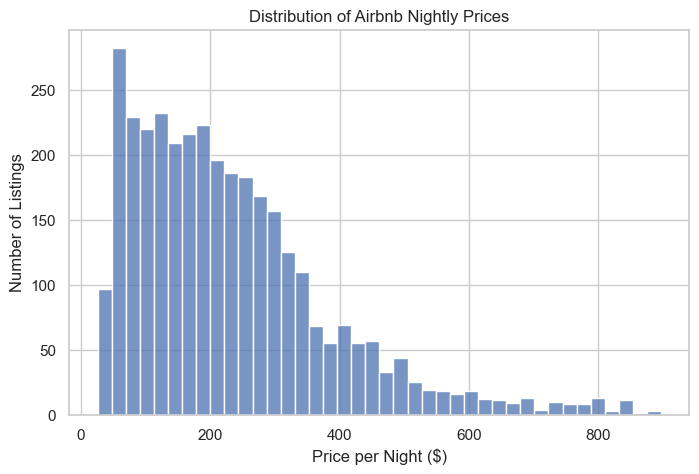

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df_model["price"], bins=40)
plt.title("Distribution of Airbnb Nightly Prices")
plt.xlabel("Price per Night ($)")
plt.ylabel("Number of Listings")
plt.show()


The distribution of nightly price is expected to be right-skewed, meaning most listings are in a lower-to-mid price range, while a smaller number of listings are much more expensive.

### 8-2: Price by Room Type
This helps show whether room type is related to nightly price.

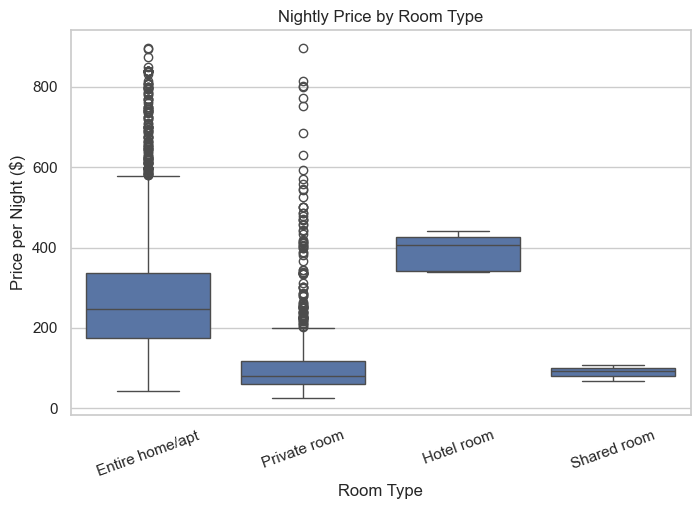

In [13]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df_model, x="room_type", y="price")
plt.title("Nightly Price by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Price per Night ($)")
plt.xticks(rotation=20)
plt.show()


This plot can show whether entire homes/apartments tend to cost more than private rooms or shared rooms. If so, room type is likely an important predictive feature.

### 8-3: Price vs Accommodates
This helps check whether larger listings tend to cost more.

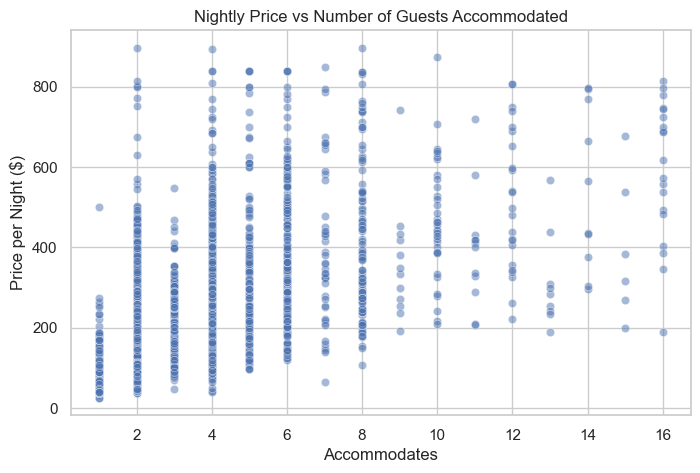

In [14]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_model, x="accommodates", y="price", alpha=0.5)
plt.title("Nightly Price vs Number of Guests Accommodated")
plt.xlabel("Accommodates")
plt.ylabel("Price per Night ($)")
plt.show()


Listings that accommodate more guests may generally be more expensive, although there may still be a lot of variation depending on location, room type, and quality.

### 8-4: Average Price by Neighborhood
This helps determine whether location appears important for pricing.

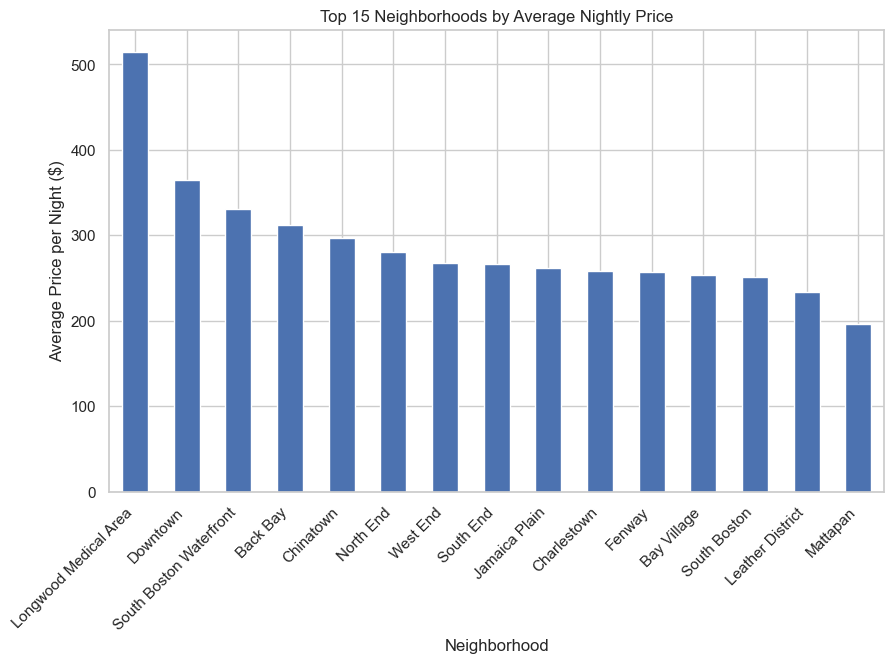

In [15]:
avg_price_by_neighborhood = (
    df_model.groupby("neighbourhood_cleansed")["price"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(10,6))
avg_price_by_neighborhood.plot(kind="bar")
plt.title("Top 15 Neighborhoods by Average Nightly Price")
plt.xlabel("Neighborhood")
plt.ylabel("Average Price per Night ($)")
plt.xticks(rotation=45, ha="right")
plt.show()

Neighborhood-level differences in average price suggest that location is likely an important driver of Airbnb pricing.